<a href="https://colab.research.google.com/github/pranavdattasharma/IIIT-AIML-Labs/blob/main/AIML_Module_3_Lab_2_Implementing_KNN_from_scratch_and_visualize_Algorithm_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
### MODULE 3: CLASSIFICATION-1
### LAB-2 : Implementing KNN from scratch and visualize Algorithm performance

---

# **Section 1: Implementing KNN**

In the last lab we had started discussing about KNN or K Nearest Neighbour method for clasification. We used the pre-built scikit-learn library for KNN. Now let's see how to implement this algorithm from scratch  

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from collections import Counter

In [9]:
def predict(X_train, y_train, X_test, k):
    distances = []
    targets = []

    for i in range(len(X_train)):
        # compute and store L2 distance
        distances.append([np.sqrt(np.sum(np.square(X_test - X_train[i, :]))), i])

    distances = sorted(distances)

    for i in range(k):
        index = distances[i][1]
        targets.append(y_train[index])

    # return most common target
    return Counter(targets).most_common(1)[0][0]

In [10]:
def k_nearest_neighbor(X_train, y_train, X_test, k):

    assert k <= len(X_train), "[!] K cannot be larger than number of samples."

    # loop over all observations
    predictions = []
    for i in range(len(X_test)):
        predictions.append(predict(X_train, y_train, X_test[i, :], k))

    return np.asarray(predictions)

**Note** : If k = 1 then the algorithm will simply return the label of the nearest neighbour. When we give k > 1 the most common label out of the given labels in the k neighbours will be selected.The code for 1 NN is given as follows and does not have to be so complicated.

In [11]:
def NN1(traindata, trainlabel, query):
  diff  = traindata - query  # find the difference between features. Numpy automatically takes care of the size here
  sq = diff*diff # square the differences
  dist = sq.sum(1) # add up the squares
  label = trainlabel[np.argmin(dist)] # our predicted label is the label of the training data which has the least distance from the query
  return label

Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm.

In [12]:
def Accuracy(gtlabel, predlabel):
  assert len(gtlabel)==len(predlabel), "Length of the groundtruth labels and predicted labels should be the same"
  correct = (gtlabel==predlabel).sum() # count the number of times the groundtruth label is equal to the predicted label.
  return correct/len(gtlabel)

## Section 1.1 - Iris Dataset
Let's try it out on Iris Dataset present in the scikit learn library

In [13]:
from sklearn.datasets import load_iris

data = load_iris()

df = pd.DataFrame(data=data.data, columns=data.feature_names)

df["target"] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [14]:
X = np.array(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']])
y = np.array(df['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=17)

In [15]:
# Making our predictions
predictions = k_nearest_neighbor(X_train, y_train, X_test, 7)

# evaluating accuracy
accuracy = Accuracy(y_test, predictions)
print("The accuracy of our classifier is {} %".format(100*accuracy))

The accuracy of our classifier is 94.0 %


Voila! You have implemented your own version of the K-Nearest Neighbours algorithm, which works very well on the Iris Dataset. Congratulations!  

Now try out the sklearn implementation and compare your results.  

In [16]:
from sklearn.neighbors import KNeighborsClassifier

sklearn_knn = KNeighborsClassifier(n_neighbors=7)
sklearn_knn.fit(X_train,y_train)
sklearn_predictions = sklearn_knn.predict(X_test)
accuracy = accuracy_score(y_test, sklearn_predictions)
print("The accuracy of Sklearn classifier is {} %".format(100*accuracy))

The accuracy of Sklearn classifier is 94.0 %


##  Section 1.2: Weighted NN
For KNN, If k is too small, the algorithm would be more sensitive to outliers. If k is too large, then the neighborhood may include too many points from other classes. We also take the label with max votes in the neighbourhood. Another choice can be that instead of giving equal weights to each of the neighbours we can give weighted points in the neighbourhood. So we weigh points by the inverse of their distance. Therefore, closer points will be given a higher priority as compared to the far off points.

An easy way to implement this is by specifying the 'weights' parameter as distance when defining the sklearn KNN function. For more information go through this [site](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

In [17]:
## TASK
## Modify the KNN function you wrote to return all the K-nearest neighbours along with their distances,
## instead of just the output that was most common. You don't need to find out accuracy, just modify the function
## and return the k-nearest neighbours and distances.

In [18]:
#TASK-I Solution

import numpy as np
from collections import Counter
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Loading Iris Dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target

# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1234
)

# Modified KNN Function
def k_nearest_neighbor(X_train, y_train, query, k):

    distances = []

    # Finding distance from query point to all training points
    for i in range(len(X_train)):

        distance = np.sqrt(np.sum((X_train[i] - query) ** 2))

        distances.append((distance, y_train[i], X_train[i]))

    # Sorting based on distance
    distances.sort(key=lambda x: x[0])

    # Taking K nearest neighbours
    k_neighbours = distances[:k]

    return k_neighbours


# Example Query Point
query = X_test[0]

# Value of K
k = 5

# Calling Function
neighbors = k_nearest_neighbor(X_train, y_train, query, k)

# Printing Results
print("K Nearest Neighbours:\n")

for i, neighbour in enumerate(neighbors):

    distance = neighbour[0]
    label = neighbour[1]
    point = neighbour[2]

    print(f"Neighbour {i+1}")
    print("Point     :", point)
    print("Class     :", label)
    print("Distance  :", distance)
    print()

K Nearest Neighbours:

Neighbour 1
Point     : [6.  2.9 4.5 1.5]
Class     : 1
Distance  : 0.19999999999999973

Neighbour 2
Point     : [6.2 2.9 4.3 1.3]
Class     : 1
Distance  : 0.34641016151377546

Neighbour 3
Point     : [6.3 3.3 4.7 1.6]
Class     : 1
Distance  : 0.4242640687119287

Neighbour 4
Point     : [6.  3.  4.8 1.8]
Class     : 2
Distance  : 0.45825756949558416

Neighbour 5
Point     : [5.7 2.8 4.5 1.3]
Class     : 1
Distance  : 0.4690415759823425



In [19]:
import numpy as np

def k_nearest_neighbor(X_train, y_train, query, k):

    distances = []

    # Finding distance of query point from all training points
    for i in range(len(X_train)):

        distance = np.sqrt(np.sum((X_train[i] - query) ** 2))

        # Store distance and corresponding label
        distances.append((distance, y_train[i]))

    # Sort based on distance
    distances = sorted(distances, key=lambda x: x[0])

    # Take first k nearest neighbours
    k_neighbours = distances[:k]

    return k_neighbours

# **Section 2: Visualizing Data**  

We will look into something called **Voronoi** diagrams.  

**Note**: Ideally, we should perform data visualization to see what the data looks like before we apply any Machine Learning algorithm.  Only for the purpose of this lab session, we're explaining it after you've applied KNN.

### Voronoi Diagrams  

In simple terms, Voronoi diagrams help you to visualize the dataset by partioning the plane into regions that are close to a given set of points. These regions are also called Voronoi cells.  

Note that the cells/regions depend on the Distance metric being used. One way of interpreting this is by understanding that the distance metric decides the degree to which a 'point' or 'seed' in the Voronoi diagram has influence.  For each seed there is a corresponding region, called a Voronoi cell, consisting of all points of the plane closer to that seed than to any other.

This [link](https://en.wikipedia.org/wiki/Voronoi_diagram#Illustration) provides a wonderful illustration of Voronoi plots for 20 points in two cases: (1) Using Euclidean distance, and (2) Using Manhattan distance.  



Since our Iris data is 4-dimensional (as it has 4 attributes), we need to convert into a form that can be represented in 2-D.   

While there are methods to visualize data higher than 2-dimensions, that is beyond scope for now.  

For simplicity, we just take the first two columns of the iris dataset attributes and observe the Voronoi diagram generated for that.  
Alternatively, one can also perform PCA (Principal Component Analysis), to reduce the 4D data to just two dimensions.

In [20]:
#@title Plotting Voronoi regions
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite voronoi regions in a 2D diagram to finite
    regions.

    Parameters
    ----------
    vor : Voronoi
        Input diagram
    radius : float, optional
        Distance to 'points at infinity'.

    Returns
    -------
    regions : list of tuples
        Indices of vertices in each revised Voronoi regions.
    vertices : list of tuples
        Coordinates for revised Voronoi vertices. Same as coordinates
        of input vertices, with 'points at infinity' appended to the
        end.

    """

    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = np.ptp(vor.points, axis=0).max()

    # Construct a map containing all ridges for a given point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruct infinite regions
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]

        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                # finite ridge: already in the region
                continue

            # Compute the missing endpoint of an infinite ridge

            t = vor.points[p2] - vor.points[p1] # tangent
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])  # normal

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_region.append(len(new_vertices))
            new_vertices.append(far_point.tolist())

        # sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)]

        # finish
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

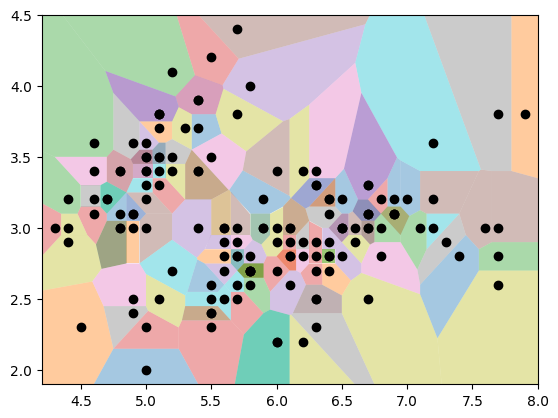

In [21]:
## Plotting Voronoi regions for the Iris dataset

points = []
xpts = np.array(df['sepal length (cm)'])
ypts = np.array(df['sepal width (cm)'])
for i in range(len(xpts)):
  points.append([xpts[i],ypts[i]])
# print(points)
points = np.array(points)
# compute Voronoi tesselation
vor = Voronoi(points)

regions,vertices = voronoi_finite_polygons_2d(vor)

for region in regions:
    polygon = vertices[region]
    plt.fill(*zip(*polygon), alpha=0.4)

plt.plot(points[:,0], points[:,1], 'ko')
plt.xlim(vor.min_bound[0] - 0.1, vor.max_bound[0] + 0.1)
plt.ylim(vor.min_bound[1] - 0.1, vor.max_bound[1] + 0.1)

plt.show()

## Section 2.2: Understanding Decision Boundaries  
So you have seen the Voronoi diagram of the dataset, implemented KNN, and also seen your algorithm's performance in terms of accuracy? Impressive!  
Wouldn't it also be great to know how exactly these 'votes' or neighbours are decided through some kind of visualization?  


### Decision Boundary

While the Voronoi diagram gave us a good idea of the points present in our dataset, to understand how KNN performed on our dataset we can plot decision boundaries. Decision boundaries, as the name suggests, divide the plane into different regions of classification.  

Note that here again, for simplicity, we have only considered first two attributes of the DataFrame (ie, Sepal Length and Sepal Width).  

In [22]:
from matplotlib.colors import ListedColormap
import seaborn as sns


def decision_boundary_plot(x_dec,y_dec,k):
  h = .02  # step size in the mesh

  # Create color maps
  n = len(set(y_dec))
  cmap_light = ListedColormap(['pink', 'green', 'cyan','yellow'][:n])
  cmap_bold = ['pink', 'darkgreen', 'blue','yellow'][:n]

  for weights in ['uniform', 'distance']:
      # we create an instance of Neighbours Classifier and fit the data.
      clf = KNeighborsClassifier(n_neighbors=k, weights=weights)
      clf.fit(x_dec, y_dec)

      # Plot the decision boundary. For that, we will assign a color to each
      # point in the mesh [x_min, x_max]x[y_min, y_max].
      x_min, x_max = x_dec[:, 0].min() - 1, x_dec[:, 0].max() + 1
      y_min, y_max = x_dec[:, 1].min() - 1, x_dec[:, 1].max() + 1
      xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
      Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

      # Put the result into a color plot
      Z = Z.reshape(xx.shape)
      plt.figure(figsize=(8, 6))
      plt.contourf(xx, yy, Z, cmap=cmap_light)

      # Plot also the training points
      sns.scatterplot(x=x_dec[:, 0], y=x_dec[:, 1], hue=y_dec,
                      palette=cmap_bold, alpha=1.0, edgecolor="black")
      plt.xlim(xx.min(), xx.max())
      plt.ylim(yy.min(), yy.max())
      plt.title("Multi-Classification (k = %i, weights = '%s')"% (k, weights))

  plt.show()


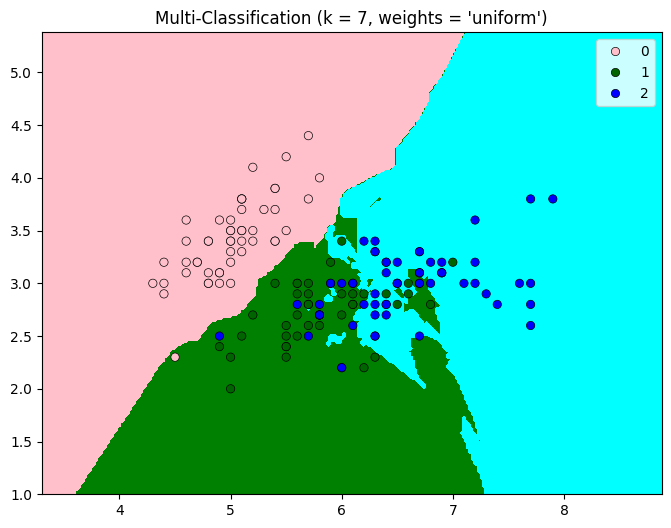

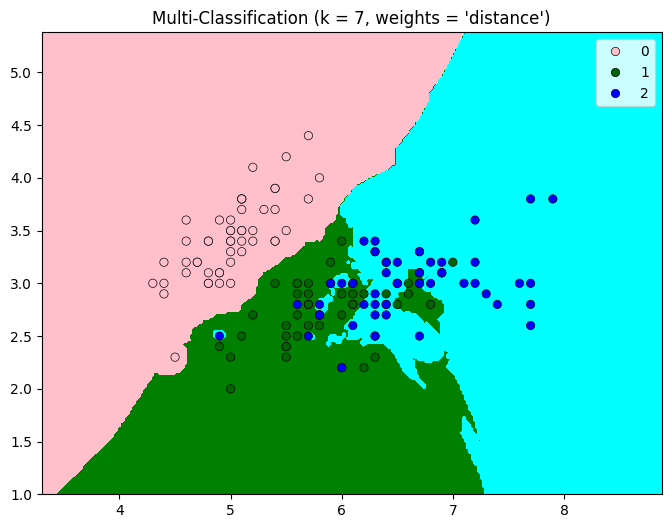

In [23]:
x_pts = X[:,:2]
y_pts = y
decision_boundary_plot(x_pts,y_pts,7)

In [24]:
## TASK-2
## In the above cells, we saw the Voronoi diagram of the data and plotted the KNN decision boundaries
## by only considering two attributes of the dataset. You must be already familiar with PCA.
## Apply PCA on the dataset above to reduce it to two dimensions.
## Plot the Voronoi diagram and Decision boundaries after that.

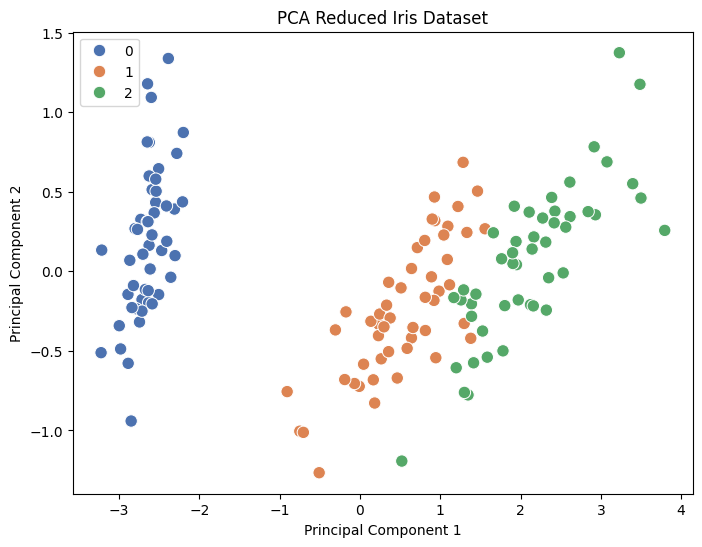

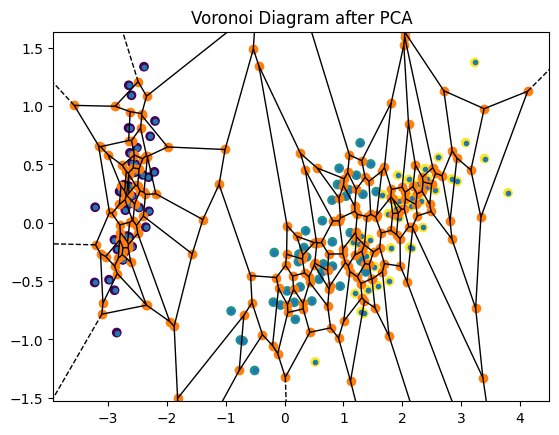

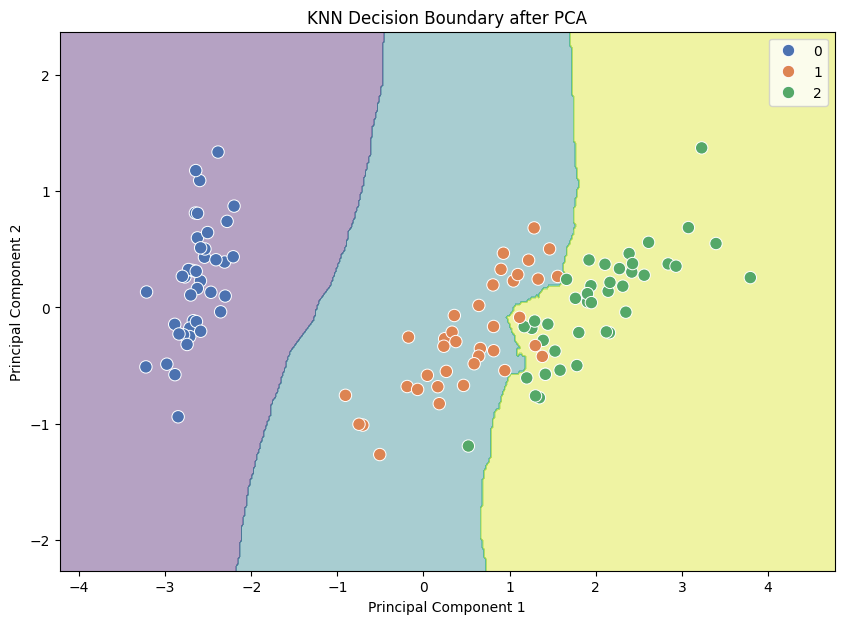

In [27]:
#TASK-2 Solution

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from scipy.spatial import Voronoi, voronoi_plot_2d


# Loading Iris Dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target


# Applying PCA to reduce dimensions to 2
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=1234
)


# -----------------------------
# Plotting PCA Reduced Dataset
# -----------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette='deep',
    s=80
)

plt.title("PCA Reduced Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()


# -----------------------------
# Voronoi Diagram
# -----------------------------

vor = Voronoi(X_train)

fig = voronoi_plot_2d(vor)

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    cmap='viridis'
)

plt.title("Voronoi Diagram after PCA")

plt.show()


# -----------------------------
# KNN Decision Boundary
# -----------------------------

# Training KNN
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


# Creating Mesh Grid
x_min, x_max = X_train[:,0].min() - 1, X_train[:,0].max() + 1
y_min, y_max = X_train[:,1].min() - 1, X_train[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)


# Predicting on Mesh Grid
Z = knn.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)


# Plotting Decision Boundary
plt.figure(figsize=(10,7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.4,
    cmap='viridis'
)

sns.scatterplot(
    x=X_train[:,0],
    y=X_train[:,1],
    hue=y_train,
    palette='deep',
    s=80
)

plt.title("KNN Decision Boundary after PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

## Section 2.3: Confusion Matrix  
In classification problems, a confusion matrix, also known as an error matrix, is a table that allows visualization of the performance of an algorithm, typically a supervised learning one. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.

In [25]:
from sklearn.metrics import confusion_matrix

In [28]:
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier


# Creating KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

# Training Model
knn.fit(X_train, y_train)

# Predicting Test Data
predictions = knn.predict(X_test)


# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:\n")
print(cm)


# Crosstab Visualization
print("\nConfusion Matrix Table:\n")

print(
    pd.crosstab(
        y_test,
        predictions,
        rownames=['True'],
        colnames=['Predicted'],
        margins=True
    )
)

Confusion Matrix:

[[ 9  0  0]
 [ 0 13  0]
 [ 0  0  8]]

Confusion Matrix Table:

Predicted  0   1  2  All
True                    
0          9   0  0    9
1          0  13  0   13
2          0   0  8    8
All        9  13  8   30


Text(0.5, 23.52222222222222, 'Predicted label')

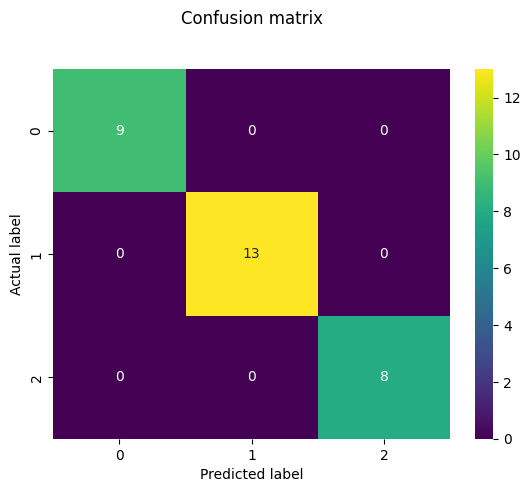

In [29]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, predictions)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="viridis" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

## Section 2.4: Classification Report

Precision, Recall, and F1-Score are other metrics besides accuracy that one might look for in an algorithm.  Depending on the use-case, one might consider one metric more important than the other.  

Note: *T-> True, F->False, P->Positive, N->Negative*
    
Mathematically, Accuracy is :  

$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$  

**Precision**: The accuracy of positive predictions


$Precision = \frac{TP}{TP+FP}$

**Recall**:Fraction of positives that were correctly identified


$Recall = \frac{TP}{TP+FN}$


**F1-score**: Harmonic mean of precision and recall  


$F1 = \frac{2*Precision*Recall}{Precision+Recall} = \frac{2*TP}{2*TP+FP+FN}$  



In [30]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### **Car Evaluation Dataset**

In [31]:
# Upload the Car evaluation data CSV file that has been shared with you.
# Run this cell, click on the 'Choose files' button and upload the file.
from google.colab import files
uploaded = files.upload()

Saving car_evaluation.csv to car_evaluation.csv


In [32]:
car_df = pd.read_csv(list(uploaded.keys())[0])
car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [33]:
for x in car_df.columns:
  # print(x)
  le = preprocessing.LabelEncoder()
  le.fit(car_df[x])
  car_df[x]=le.transform(car_df[x])

car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,3,3,0,0,2,2,2
1,3,3,0,0,2,0,2
2,3,3,0,0,1,1,2
3,3,3,0,0,1,2,2
4,3,3,0,0,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,3,2,1,2,1
1723,1,1,3,2,1,0,3
1724,1,1,3,2,0,1,2
1725,1,1,3,2,0,2,1


In [34]:
dataset = car_df.values
X = dataset[:,0:6]
y = np.array(dataset[:,6])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
score = accuracy_score(y_test, predictions)
print("The accuracy of the classifier on Car evaluation dataset is {:.2f} %".format(100*score))

The accuracy of the classifier on Car evaluation dataset is 89.88 %


Confusion Matrix:

[[ 51   0  20   1]
 [  6   3   2   0]
 [  2   0 246   0]
 [  5   1   4   5]]


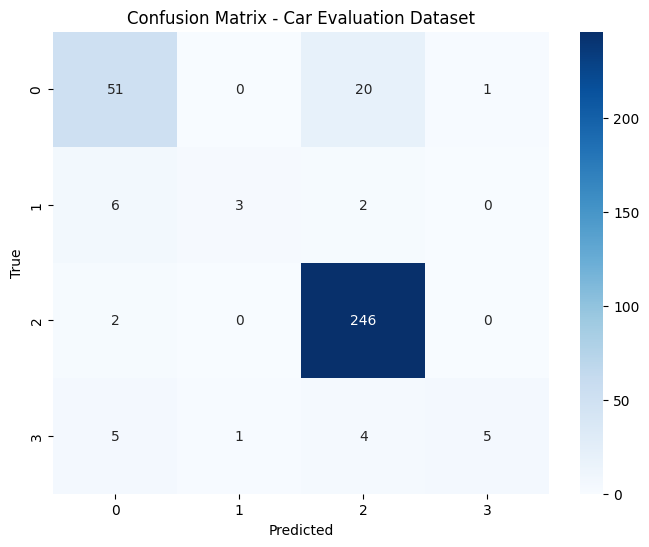

In [36]:
## TASK-3
## Plot a Confusion Matrix for the results of the Car evaluation dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix


# Loading Dataset
car_df = pd.read_csv("car_evaluation.csv")


# Label Encoding
le = preprocessing.LabelEncoder()

for column in car_df.columns:
    car_df[column] = le.fit_transform(car_df[column])


# Separating Features and Target
X = car_df.iloc[:, :-1]
y = car_df.iloc[:, -1]


# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1234
)


# Training KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


# Predictions
predictions = knn.predict(X_test)


# Creating Confusion Matrix
cm = confusion_matrix(y_test, predictions)


# Printing Confusion Matrix
print("Confusion Matrix:\n")
print(cm)


# Plotting Confusion Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Car Evaluation Dataset")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [37]:
## TASK-4
## Print a Classification Report for the results of the Car evaluation dataset
from sklearn.metrics import classification_report


# Printing Classification Report
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        predictions
    )
)

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        72
           1       0.75      0.27      0.40        11
           2       0.90      0.99      0.95       248
           3       0.83      0.33      0.48        15

    accuracy                           0.88       346
   macro avg       0.82      0.58      0.64       346
weighted avg       0.87      0.88      0.87       346



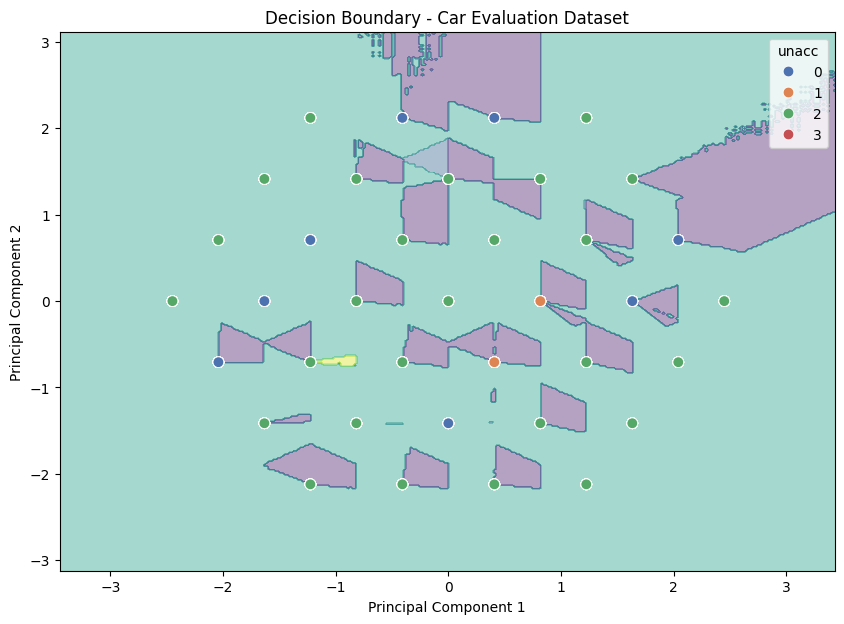

In [39]:
## TASK-5
## Plot the Decision boundary diagram for the classifier of the Car evaluation dataset
from sklearn.decomposition import PCA


# Reducing Car Dataset to 2 Dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


# Splitting PCA Data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=1234
)


# Training KNN
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


# Creating Mesh Grid
x_min, x_max = X_train[:,0].min() - 1, X_train[:,0].max() + 1
y_min, y_max = X_train[:,1].min() - 1, X_train[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)


# Predicting Mesh Grid
Z = knn.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)


# Plotting Decision Boundary
plt.figure(figsize=(10,7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.4,
    cmap='viridis'
)

sns.scatterplot(
    x=X_train[:,0],
    y=X_train[:,1],
    hue=y_train,
    palette='deep',
    s=60
)

plt.title("Decision Boundary - Car Evaluation Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

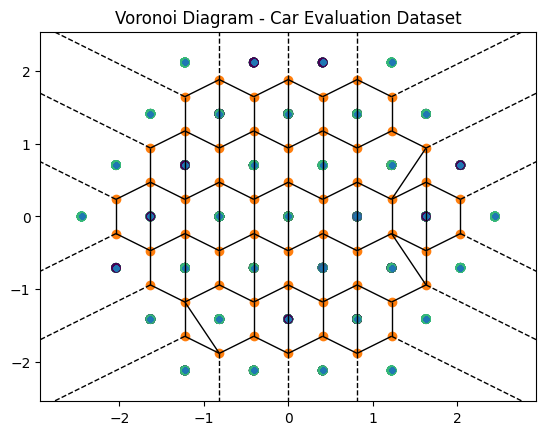

In [40]:
## TASK-6
## Plot the Voronoi diagram for the classifier of the Car evaluation dataset
from scipy.spatial import Voronoi, voronoi_plot_2d


# Creating Voronoi Diagram
vor = Voronoi(X_train)


# Plotting Voronoi Diagram
fig = voronoi_plot_2d(vor)

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    cmap='viridis'
)

plt.title("Voronoi Diagram - Car Evaluation Dataset")

plt.show()

## **Homework Assignment: Exploring Distance Metrics and KNN**

---

### **Problem 1: Implementing Custom Distance Metrics**

In this exercise, you'll implement distance metrics from scratch to deepen your understanding.

**Task 1.1:** Implement the Minkowski distance formula without using any library functions (except basic numpy operations).

Recall that Minkowski distance is defined as:

$$d(x, x') = \left(\sum_{j=1}^{D} |x_j - x'_j|^p\right)^{1/p}$$

where $p$ is a parameter. When $p=1$, it's Manhattan distance, and when $p=2$, it's Euclidean distance.

In [42]:
## HOMEWORK TASK 1.1
## Implement the Minkowski distance function below
## Test it with p=1 (should match Manhattan) and p=2 (should match Euclidean)
## Expected number of lines: 3-5

import numpy as np
from scipy.spatial import distance


def minkowski_distance(x1, x2, p):
    """
    Calculate Minkowski distance between two points.
    """

    return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)


# Test your implementation
x_1 = np.array([1, 2, 3])
x_2 = np.array([4, 6, 8])


# Test with p=1 (Manhattan)
print("Minkowski distance (p=1):", minkowski_distance(x_1, x_2, 1))
print("Manhattan distance:", distance.cityblock(x_1, x_2))
print()


# Test with p=2 (Euclidean)
print("Minkowski distance (p=2):", minkowski_distance(x_1, x_2, 2))
print("Euclidean distance:", distance.euclidean(x_1, x_2))

Minkowski distance (p=1): 12.0
Manhattan distance: 12

Minkowski distance (p=2): 7.0710678118654755
Euclidean distance: 7.0710678118654755


---

### **Problem 2: Visualizing Decision Boundaries**

Understanding how KNN makes predictions is crucial. In this exercise, you'll visualize decision boundaries for different values of K.

**Task 2.1:** Create a function that visualizes the decision boundary of a KNN classifier on 2D data.

**Hint:** You'll need to:
1. Create a mesh grid covering the feature space
2. Train a KNN classifier
3. Predict the class for each point in the mesh
4. Plot the results using `plt.contourf()` for the decision boundary
5. Overlay the training data points

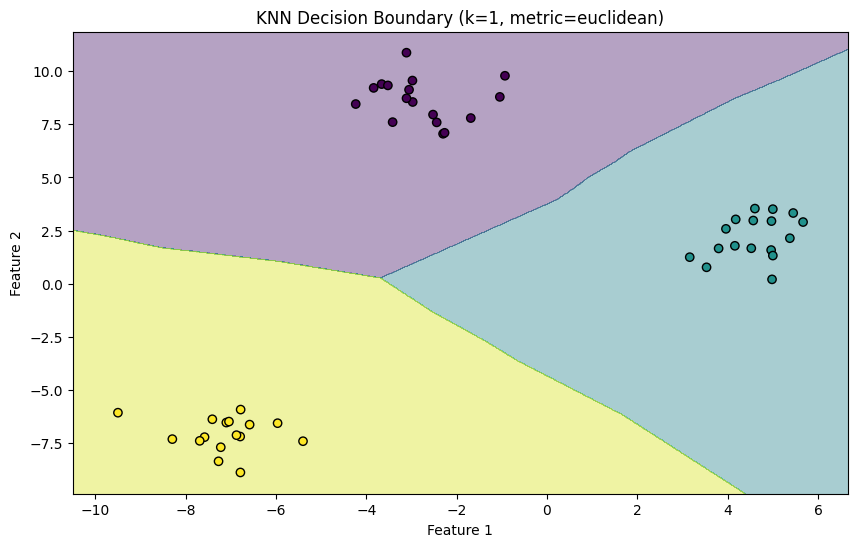

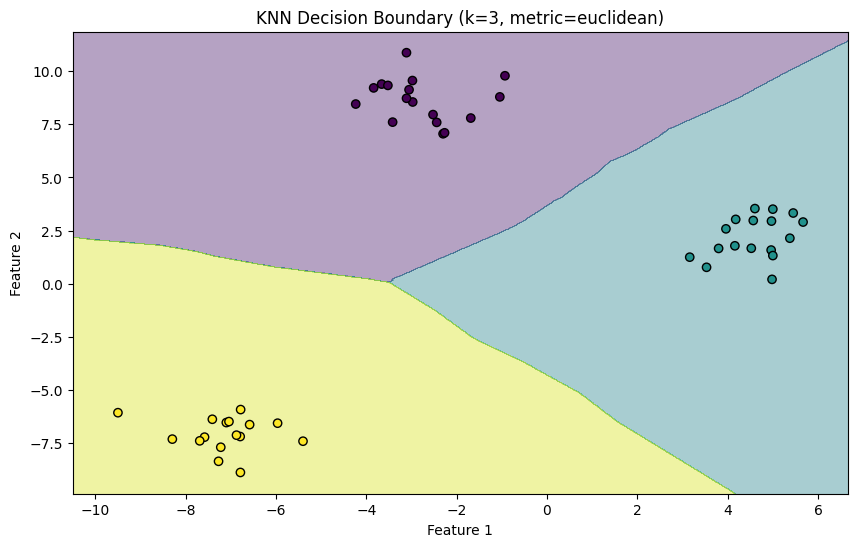

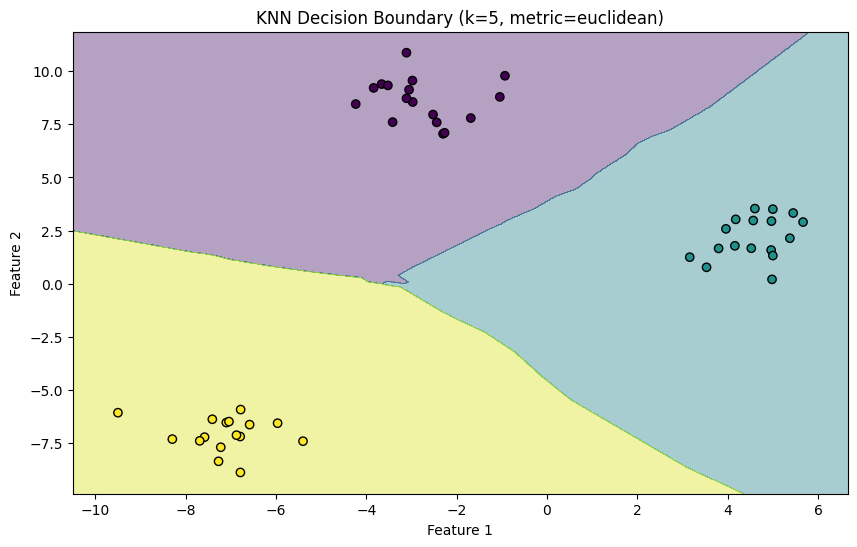

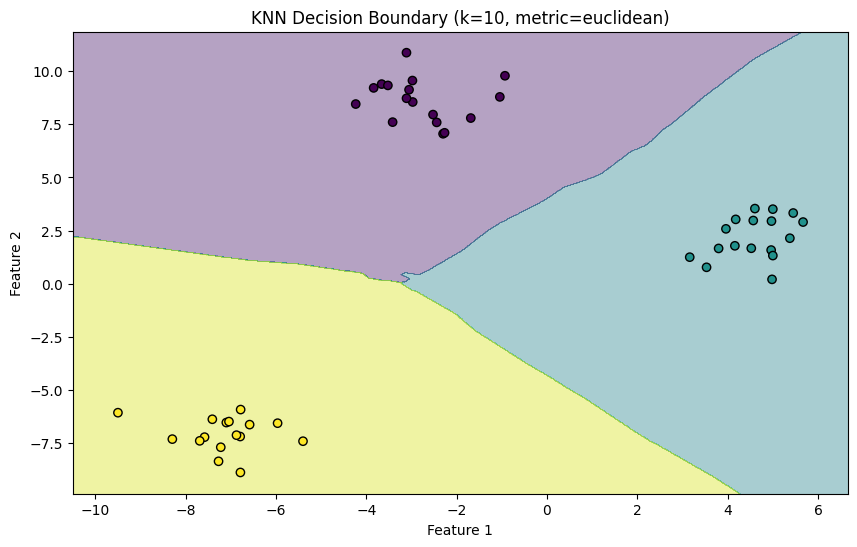

In [46]:
## HOMEWORK TASK 2.1
## Complete the function below to visualize KNN decision boundaries
## The function should create a mesh grid and predict class for each point

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier


# Function to Generate Synthetic Data
def generate_synth_data(n):

    pts, tgts = make_blobs(
        n_samples=n,
        centers=3,
        n_features=2,
        random_state=42
    )

    return pts, tgts


# Function to Plot Decision Boundary
def plot_decision_boundary(X, y, k_value, metric='euclidean'):
    """
    Plot the decision boundary for KNN classifier.
    """

    # Create a mesh grid
    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Train KNN classifier
    knn = KNeighborsClassifier(
        n_neighbors=k_value,
        metric=metric
    )

    knn.fit(X, y)

    # Predict for each point in mesh
    Z = knn.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    # Plot decision boundary and training points
    plt.figure(figsize=(10, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.4,
        cmap='viridis'
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap='viridis',
        edgecolors='k'
    )

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    plt.title(f'KNN Decision Boundary (k={k_value}, metric={metric})')

    plt.show()


# Generate synthetic data
n = 50

pts, tgts = generate_synth_data(n)


# Test with different k values
for k in [1, 3, 5, 10]:

    plot_decision_boundary(pts, tgts, k)

**Discussion Questions:**
1. **What happens to the decision boundary as K increases? Is it smoother or more irregular?**

**Ans)** As the value of K increases, the decision boundary becomes smoother. For small values like K=1, the boundary becomes very irregular and sensitive to noise because the classifier depends on only one nearest neighbor. This can lead to overfitting. When K becomes larger, the classifier considers more neighboring points, so the boundary becomes more stable and smooth.


**2. Which K value seems to generalize better without overfitting?**

**Ans)** K values like 3 or 5 seem to generalize better. Very small K values such as 1 may overfit the training data, while very large K values may underfit and ignore important patterns. Moderate K values balance both situations and give better prediction performance on unseen data.

3. Try changing the metric to 'manhattan' - how does the boundary change?

**Ans)** When the metric is changed to Manhattan distance, the decision boundary changes shape slightly. Euclidean distance measures straight-line distance, while Manhattan distance measures distance along horizontal and vertical paths. Because of this, the boundaries created using Manhattan distance look more box-shaped or rectangular compared to the smoother curved boundaries produced by Euclidean distance.

---

### **Problem 3: Impact of Distance Metrics on High-Dimensional Data**

The "curse of dimensionality" affects distance metrics differently. Let's explore this phenomenon.

**Task 3.1:** Create a function that generates random high-dimensional data and compares how different distance metrics behave as dimensionality increases.

**Background:** In high dimensions, the ratio between the maximum and minimum distances between points tends to approach 1, making it harder to distinguish between near and far neighbors. This affects different metrics differently.

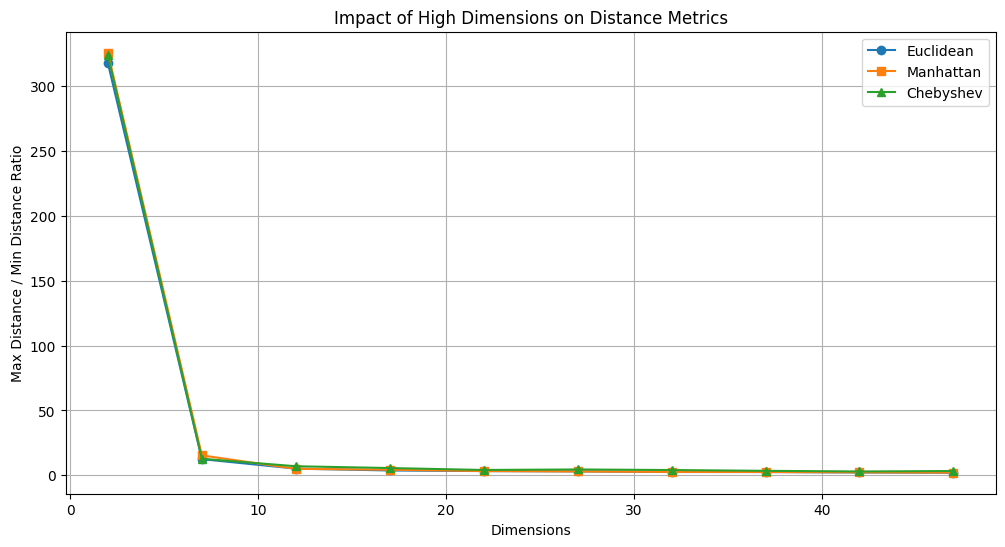

In [47]:
## HOMEWORK TASK 3.1
## Complete the function to analyze distance metrics in high dimensions
## Calculate the ratio of max distance to min distance for each metric

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import distance


def analyze_distance_in_high_dims(max_dim=50, n_points=100):
    """
    Analyze how distance metrics behave in high dimensions.
    """

    dimensions = range(2, max_dim+1, 5)

    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:

        # Generate random points
        points = np.random.randn(n_points, dim)

        euclidean_distances = []
        manhattan_distances = []
        chebyshev_distances = []

        # Calculate pairwise distances
        for i in range(n_points):

            for j in range(i + 1, n_points):

                euclidean_distances.append(
                    distance.euclidean(points[i], points[j])
                )

                manhattan_distances.append(
                    distance.cityblock(points[i], points[j])
                )

                chebyshev_distances.append(
                    distance.chebyshev(points[i], points[j])
                )

        # Store ratio of max/min distance
        results['euclidean'].append(
            max(euclidean_distances) / min(euclidean_distances)
        )

        results['manhattan'].append(
            max(manhattan_distances) / min(manhattan_distances)
        )

        results['chebyshev'].append(
            max(chebyshev_distances) / min(chebyshev_distances)
        )

    # Plot results
    plt.figure(figsize=(12, 6))

    plt.plot(
        dimensions,
        results['euclidean'],
        marker='o',
        label='Euclidean'
    )

    plt.plot(
        dimensions,
        results['manhattan'],
        marker='s',
        label='Manhattan'
    )

    plt.plot(
        dimensions,
        results['chebyshev'],
        marker='^',
        label='Chebyshev'
    )

    plt.xlabel("Dimensions")
    plt.ylabel("Max Distance / Min Distance Ratio")

    plt.title("Impact of High Dimensions on Distance Metrics")

    plt.legend()

    plt.grid(True)

    plt.show()

    return results


# Run the analysis
results = analyze_distance_in_high_dims()

### Questions to Think About and Answer
1. In the section on Decision boundaries, you must have seen that we ran the KNN algorithm twice: first with the _weights_ set to 'uniform' and then set to 'distance'. Find out the difference between these two.  

**Ans)** In KNN, when the weights are set to 'uniform', all the nearest neighbors are given equal importance. This means every neighbor contributes equally to the final prediction, regardless of how far or close it is to the query point.

When the weights are set to 'distance', closer neighbors are given more importance than farther neighbors. Points that are very near to the query point have a stronger influence on prediction, while distant neighbors contribute less.

Because of this, the decision boundary with distance weighting usually becomes more flexible and sensitive to nearby data points compared to uniform weighting.


2. What do you think could be the drawbacks of using KNN ?

**Ans)** One major drawback of KNN is that it becomes slow for large datasets because it has to calculate distances from the test point to all training points every time prediction is made.

Another drawback is that KNN is sensitive to noisy data and outliers, especially when the value of K is very small. Incorrect or noisy points can affect predictions easily.

KNN also suffers from the curse of dimensionality. When the number of features increases, distances between points become less meaningful, making it difficult to identify true nearest neighbors.

Additionally, choosing the correct value of K is important. A very small K may lead to overfitting, while a very large K may lead to underfitting.

### Useful Resources for further reading
1. Interactive KNN visualization, with class boundaries: http://vision.stanford.edu/teaching/cs231n-demos/knn/  
